In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
data =pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data" ,header=None ,names=['sepal_length','sepal_width','petal_length','petal_width','species'])
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
data.shape

(150, 5)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
np.unique(data['species'])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [6]:
# label encode the target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['species'] =le.fit_transform(data['species'])
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
features = data.iloc[:,:-1]
prediction =data.iloc[:,-1]

In [8]:
prediction.head()

0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64

In [9]:
# feature scaling using standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(features)
feature_scaled = pd.DataFrame(feature_scaled,columns=features.columns)
feature_scaled.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(feature_scaled,prediction,test_size=0.2,random_state=50,shuffle=True)

In [11]:
# perform EDA
Train_data = pd.concat([x_train,y_train],axis='columns',names=[features.columns,'species'])
Train_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
125,1.643844,0.337848,1.274550,0.790591,2
98,-0.900681,-1.281972,-0.431421,-0.129720,1
73,0.310998,-0.587764,0.535296,0.001753,1
144,1.038005,0.569251,1.103953,1.710902,2
21,-0.900681,1.494863,-1.284407,-1.050031,0


In [12]:
Train_data.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,-0.063613,0.008099,-0.028149,-0.023446,1.000000
std,1.000533,0.999773,1.000192,0.997969,0.830106
min,-1.870024,-2.438987,-1.568735,-1.444450,0.000000
25%,-0.900681,-0.587764,-1.284407,-1.181504,0.000000
50%,-0.113090,-0.124958,0.279400,0.133226,1.000000
75%,0.674501,0.627102,0.762759,0.790591,2.000000
max,2.249683,3.114684,1.672610,1.710902,2.000000


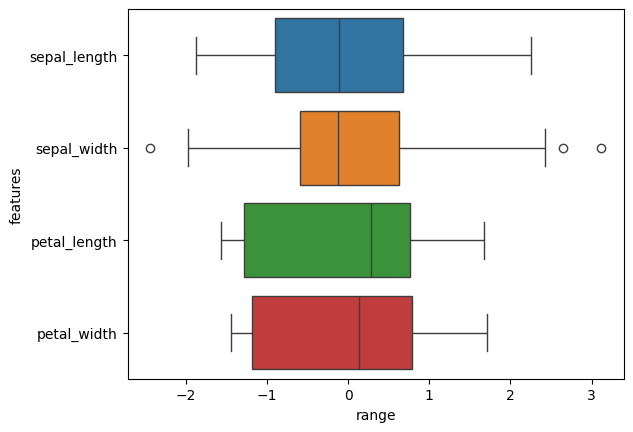

In [13]:
import seaborn as sns
sns.boxplot(data=x_train,orient='h').set(xlabel='range',ylabel='features')
plt.show()

In [18]:
# define function to extract outlier using IQR
def get_outliers_IQR(x):
    q1 = np.quantile(x,0.25)
    q3 =np.quantile(x,0.75)
    median =np.median(x)
    iqr =q3-q1
    upper_bound =q3+(1.5*iqr)
    lower_bound =q1-(1.5*iqr)

    outliers = x[(x<lower_bound)|(x>upper_bound)]
    outlier_indices =np.where((x<lower_bound)|(x>upper_bound))

    return outliers,outlier_indices[0].tolist()

In [19]:
Train_copy = Train_data.copy()
Train_copy.reset_index(drop=True, inplace=True)

# Calling the 'get_outlier function'
outliers, outlier_indices = get_outliers_IQR(Train_copy['sepal_width'].to_numpy())

# Print the outliers and the corresponding indices
print('The outliers in the feature "sepal_width" are: ', outliers)
print('These are available on indexes: ', outlier_indices)

The outliers in the feature "sepal_width" are:  [ 3.11468391 -2.43898725  2.65187798]
These are available on indexes:  [22, 89, 117]


In [21]:
Train_copy.drop(outlier_indices,inplace=True)
Train_copy.reset_index(drop=True,inplace=True)

In [22]:
Train_copy

,sepal_length,sepal_width,petal_length,petal_width,species
0,1.643844,0.337848,1.274550,0.790591,2
1,-0.900681,-1.281972,-0.431421,-0.129720,1
2,0.310998,-0.587764,0.535296,0.001753,1
3,1.038005,0.569251,1.103953,1.710902,2
4,-0.900681,1.494863,-1.284407,-1.050031,0
...,...,...,...,...,...
112,1.038005,-0.124958,0.819624,1.447956,2
113,0.068662,0.337848,0.592162,0.790591,1
114,0.674501,-0.587764,1.047087,1.316483,2
115,1.643844,1.263460,1.331416,1.710902,2


In [23]:
Train_copy.shape

(117, 5)

In [24]:
Train_data.shape

(120, 5)

In [25]:
X_train = Train_copy.iloc[:,:-1]
y_train =Train_copy.iloc[:,-1]

In [26]:
y_train

0      2
1      1
2      1
3      2
4      0
      ..
112    2
113    1
114    2
115    2
116    2
Name: species, Length: 117, dtype: int64

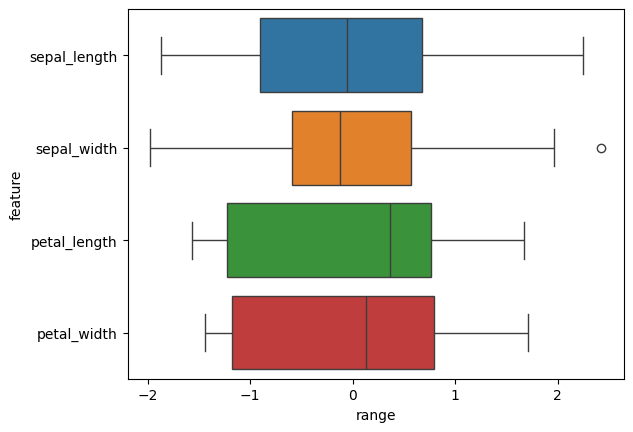

In [27]:
sns.boxplot(X_train,orient='h').set(xlabel="range",ylabel="feature")
plt.show()

In [29]:
# Calling the 'get_outlier function'
outliers, outlier_indices = get_outliers_IQR(Train_copy['sepal_length'].to_numpy())

# Print the outliers and the corresponding indices
print('The outliers in the feature "sepal_width" are: ', outliers)
print('These are available on indexes: ', outlier_indices)

The outliers in the feature "sepal_width" are:  []
These are available on indexes:  []


In [33]:
# Calling the 'get_outlier function'
outliers, outlier_indices = get_outliers_IQR(Train_copy['sepal_width'].to_numpy())

# Print the outliers and the corresponding indices
print('The outliers in the feature "sepal_width" are: ', outliers)
print('These are available on indexes: ', outlier_indices)

The outliers in the feature "sepal_width" are:  [2.42047502]
These are available on indexes:  [46]


In [34]:
Train_copy.drop(outlier_indices,inplace=True)
Train_copy.reset_index(drop=True,inplace=True)
Train_copy

,sepal_length,sepal_width,petal_length,petal_width,species
0,1.643844,0.337848,1.274550,0.790591,2
1,-0.900681,-1.281972,-0.431421,-0.129720,1
2,0.310998,-0.587764,0.535296,0.001753,1
3,1.038005,0.569251,1.103953,1.710902,2
4,-0.900681,1.494863,-1.284407,-1.050031,0
...,...,...,...,...,...
111,1.038005,-0.124958,0.819624,1.447956,2
112,0.068662,0.337848,0.592162,0.790591,1
113,0.674501,-0.587764,1.047087,1.316483,2
114,1.643844,1.263460,1.331416,1.710902,2


In [35]:
# update X_train y_train
X_train = Train_copy.iloc[:,:-1]
y_train =Train_copy.iloc[:,-1]

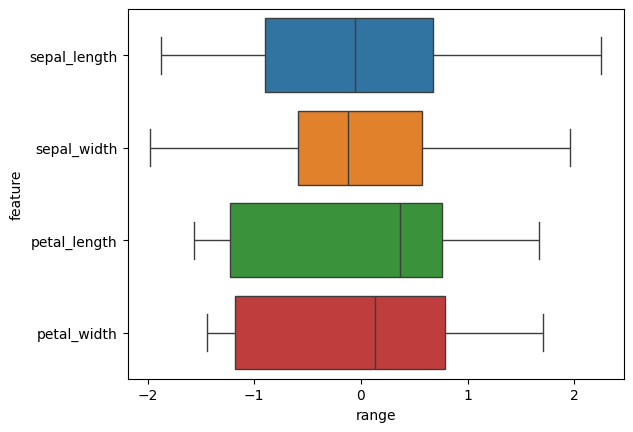

In [36]:
sns.boxplot(X_train,orient='h').set(xlabel="range",ylabel="feature")
plt.show()

In [37]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2]), array([38, 37, 41]))

In [38]:
classes, count = np.unique(y_train, return_counts=True)
count

array([38, 37, 41])

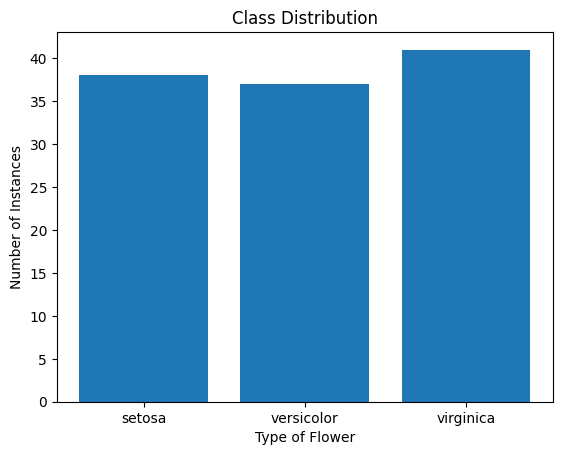

In [39]:
# plot the class distribution
plt.bar(['setosa', 'versicolor', 'virginica'], count)
plt.title('Class Distribution')
plt.xlabel('Type of Flower')
plt.ylabel('Number of Instances')
plt.show()

In [40]:
# Perform correlation analysis between numerical features
corr_mat = Train_copy.corr(method='pearson') # Pearson correlation is used
corr_mat

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,-0.127313,0.883475,0.825971,0.793662
sepal_width,-0.127313,1.000000,-0.398315,-0.330258,-0.414335
petal_length,0.883475,-0.398315,1.000000,0.959186,0.948916
petal_width,0.825971,-0.330258,0.959186,1.000000,0.955052
species,0.793662,-0.414335,0.948916,0.955052,1.000000


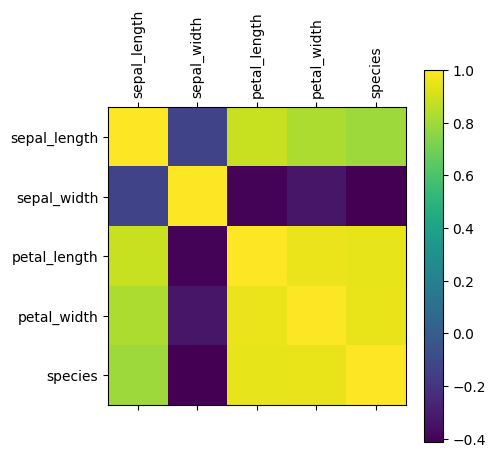

In [41]:
# Visualize the correlation matrix
plt.matshow(corr_mat)
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.columns)), corr_mat.columns)
plt.colorbar()
plt.show()

[]

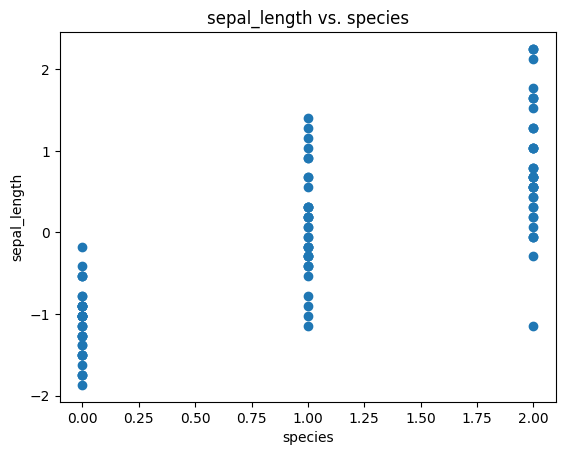

In [42]:
plt.scatter(y_train, X_train['sepal_length'])
plt.title("sepal_length vs. species")
plt.xlabel("species")
plt.ylabel("sepal_length")
plt.plot()

[]

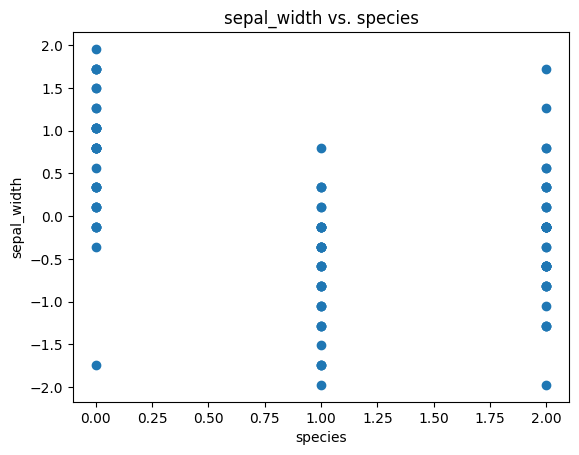

In [45]:
plt.scatter(y_train, X_train['sepal_width'])
plt.title("sepal_width vs. species")
plt.xlabel("species")
plt.ylabel("sepal_width")
plt.plot()

[]

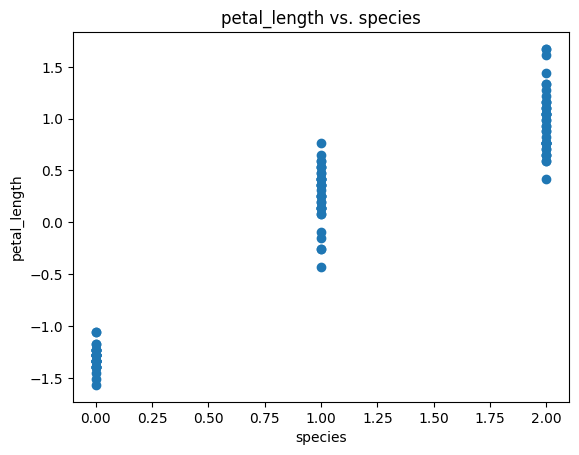

In [46]:
plt.scatter(y_train, X_train['petal_length'])
plt.title("petal_length vs. species")
plt.xlabel("species")
plt.ylabel("petal_length")
plt.plot()

[]

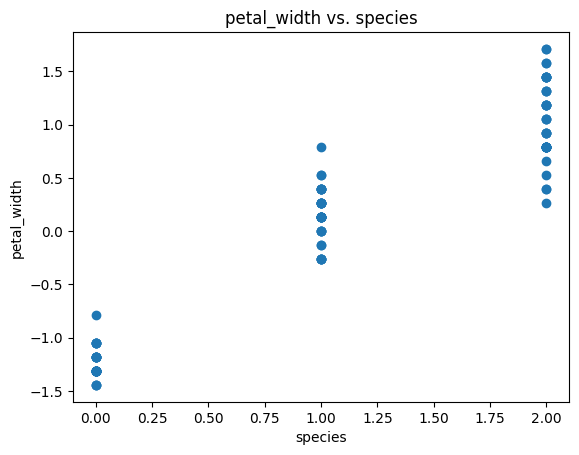

In [47]:
plt.scatter(y_train, X_train['petal_width'])
plt.title("petal_width vs. species")
plt.xlabel("species")
plt.ylabel("petal_width")
plt.plot()

In [48]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred_train =model.predict(X_train)
y_pred =model.predict(x_test)

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on test data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.933
Test confusion matrix: 
 [[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]


In [51]:
# solver='saga', random_state=0, penalty=None

model = LogisticRegression(solver='saga', random_state=0, penalty=None) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(x_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.983
Train confusion matrix: 
 [[38  0  0]
 [ 0 36  1]
 [ 0  1 40]]
Test accuracy:  0.9
Test confusion matrix: 
 [[9 0 0]
 [0 9 3]
 [0 0 9]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [52]:
# solver='saga', random_state=0, penalty=None ,max_iter =1100

model = LogisticRegression(solver='saga', random_state=0, penalty=None,max_iter=1100) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(x_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.983
Train confusion matrix: 
 [[38  0  0]
 [ 0 36  1]
 [ 0  1 40]]
Test accuracy:  0.9
Test confusion matrix: 
 [[9 0 0]
 [0 9 3]
 [0 0 9]]
